# Beach Squeeze Plot

This notebook plots change in waterline-to-seawall distance through time.
- Translucent lines: individual transects
- Solid lines: beach average
- Zero line: initial transect position (delta = 0)

In [2]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Resolve CSV path robustly whether notebook is run from notebooks/ or elsewhere
candidate_paths = [
    Path('../data/seawall_distance.csv'),
    Path('data/seawall_distance.csv'),
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p.resolve()
        break

if csv_path is None:
    raise FileNotFoundError('Could not find seawall_distance.csv in ../data or data.')

df = pd.read_csv(csv_path)
df['dates'] = pd.to_datetime(df['dates'], utc=True, errors='coerce')
df = df.dropna(subset=['dates']).sort_values('dates')

transect_columns = [c for c in df.columns if c != 'dates']
grouped = defaultdict(list)
for col in transect_columns:
    if '-' not in col:
        continue
    beach_id = col.split('-', maxsplit=1)[0]
    grouped[beach_id].append(col)

grouped = dict(grouped)
print(f'Loaded {len(df)} records from {csv_path}')
print(f'Number of beaches: {len(grouped)}')
print(f'Total transects: {sum(len(v) for v in grouped.values())}')

Loaded 1998 records from /mnt/CoastSat/seawallsqueeze/data/seawall_distance.csv
Number of beaches: 14
Total transects: 83


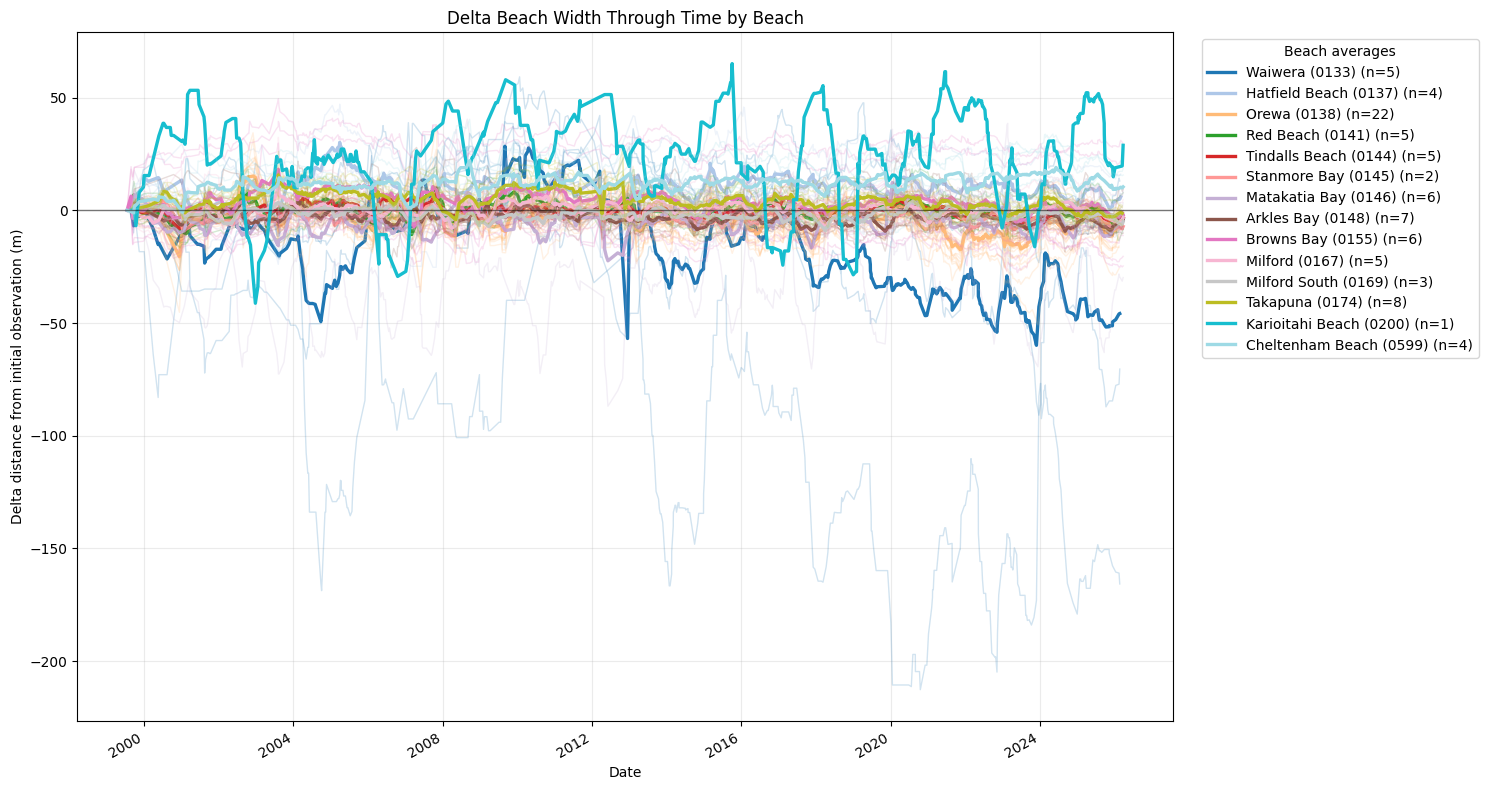

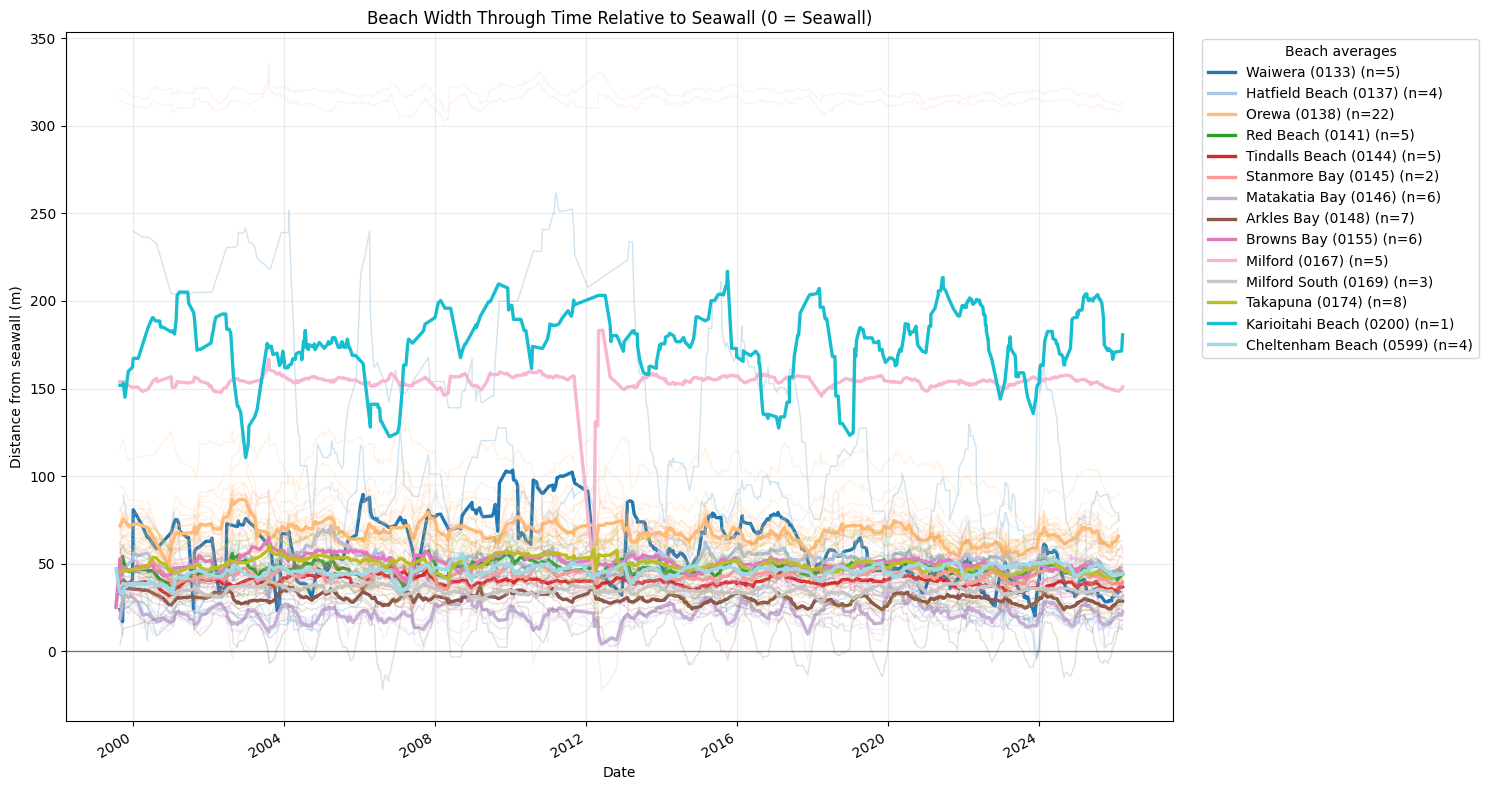

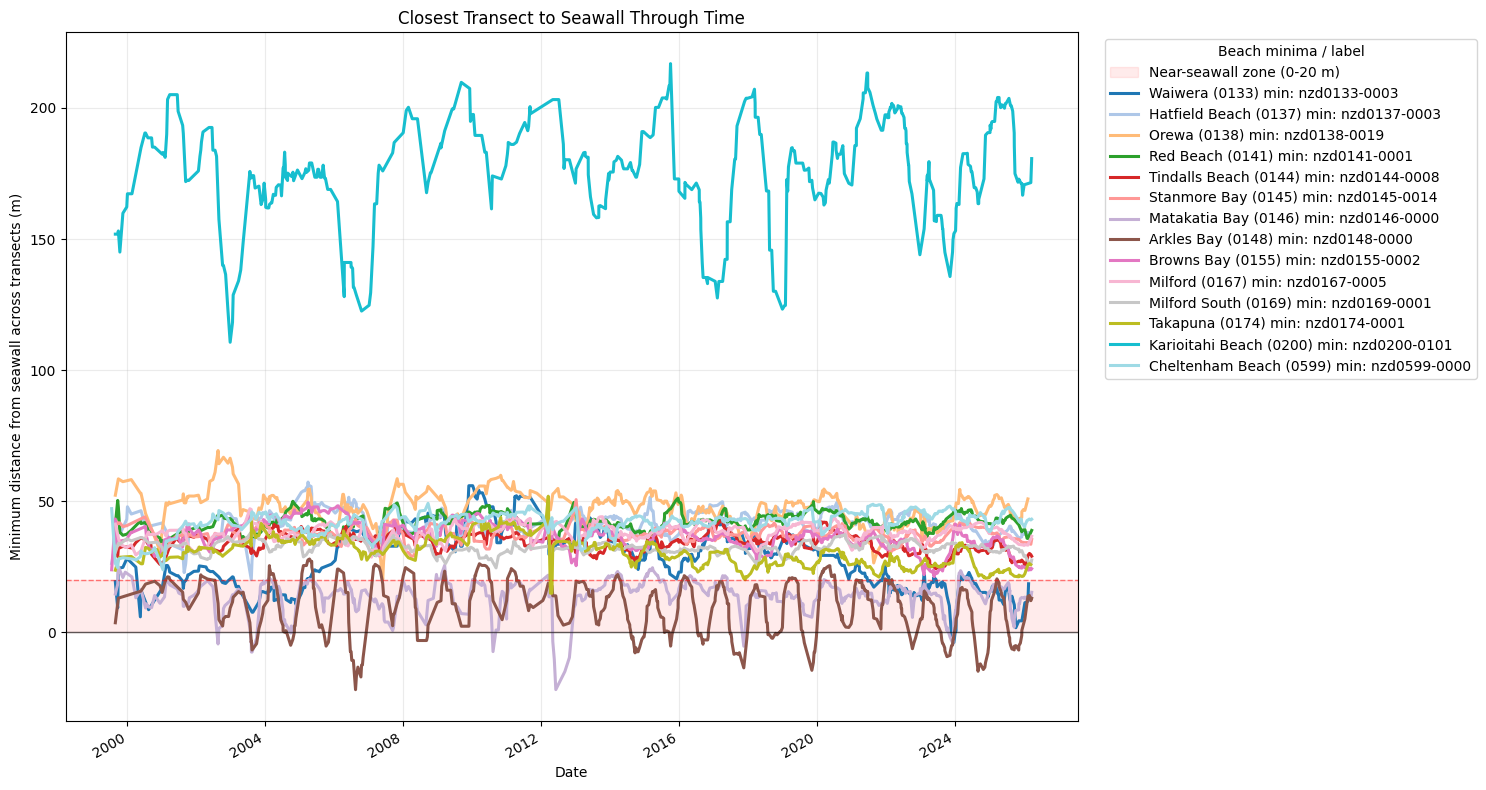

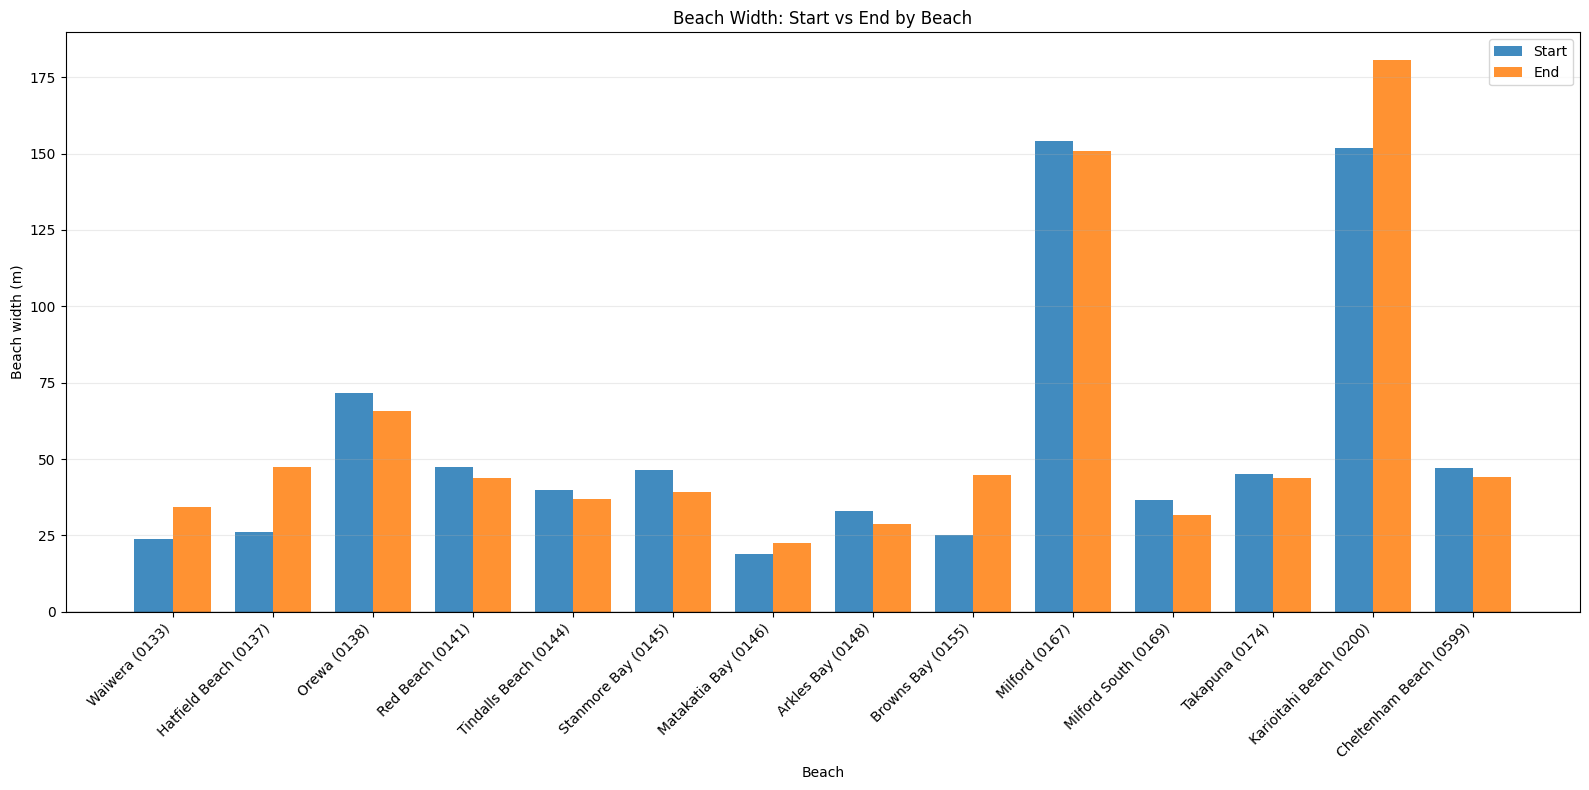

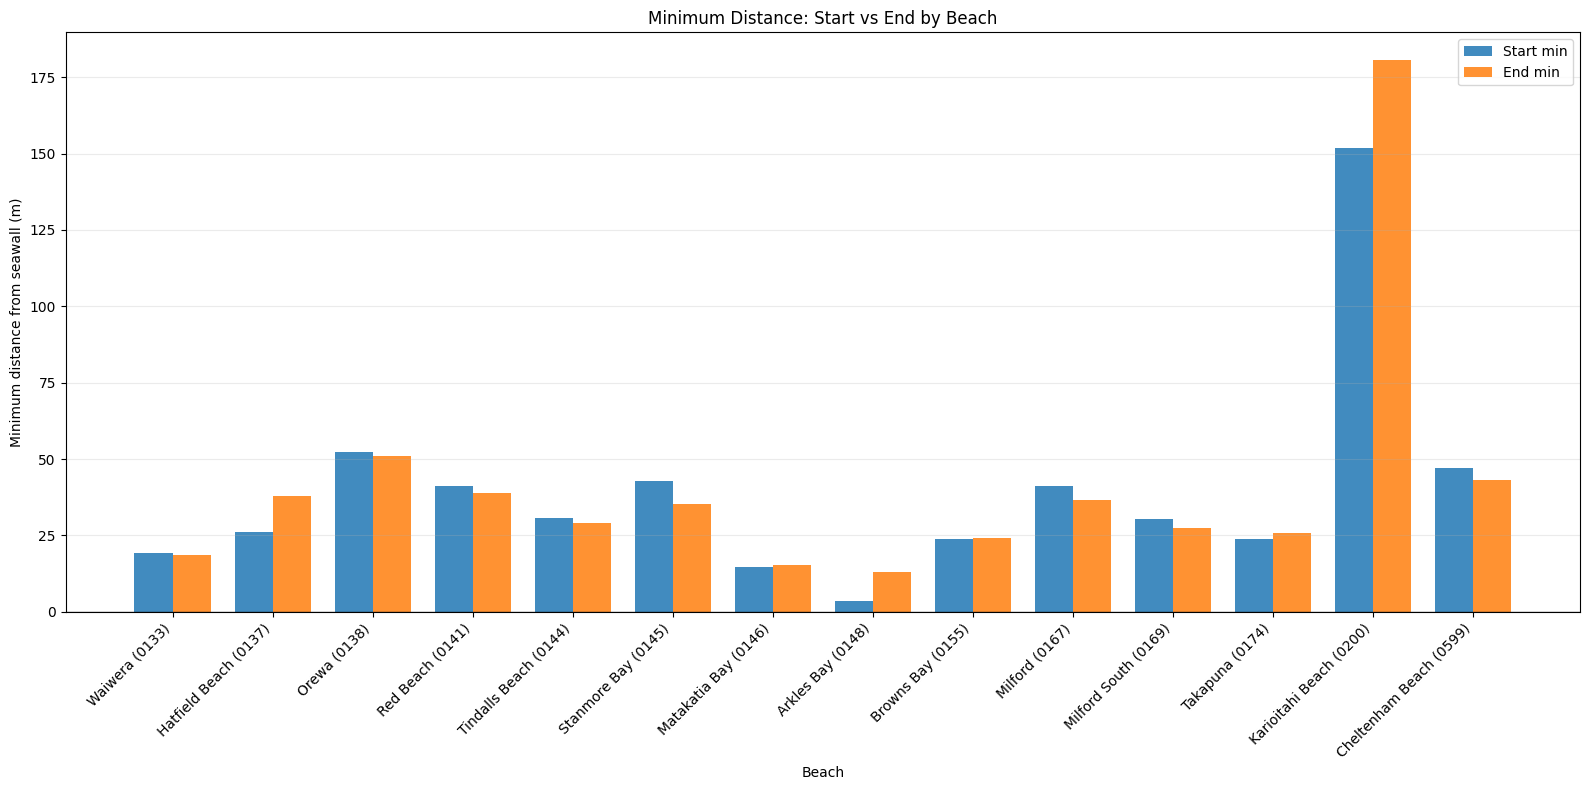

In [4]:
fig, ax = plt.subplots(figsize=(15, 8))
color_map = plt.get_cmap('tab20', len(grouped))
beach_label_map = {
    'nzd0133': 'Waiwera (0133)',
    'nzd0137': 'Hatfield Beach (0137)',
    'nzd0138': 'Orewa (0138)',
    'nzd0141': 'Red Beach (0141)',
    'nzd0144': 'Tindalls Beach (0144)',
    'nzd0145': 'Stanmore Bay (0145)',
    'nzd0146': 'Matakatia Bay (0146)',
    'nzd0148': 'Arkles Bay (0148)',
    'nzd0155': 'Browns Bay (0155)',
    'nzd0167': 'Milford (0167)',
    'nzd0169': 'Milford South (0169)',
    'nzd0174': 'Takapuna (0174)',
    'nzd0200': 'Karioitahi Beach (0200)',
    'nzd0599': 'Cheltenham Beach (0599)',
}

for idx, beach_id in enumerate(sorted(grouped)):
    cols = sorted(grouped[beach_id])
    beach_data = df[cols].apply(pd.to_numeric, errors='coerce')

    # Delta beach width: each transect starts at 0 at first valid value
    beach_delta = beach_data.apply(
        lambda s: s - s.dropna().iloc[0] if s.notna().any() else s
    )

    color = color_map(idx)

    # Individual transects: translucent
    for col in cols:
        valid = beach_delta[col].notna()
        ax.plot(
            df.loc[valid, 'dates'],
            beach_delta.loc[valid, col],
            color=color,
            alpha=0.2,
            linewidth=1.0,
        )

    # Beach average: solid, same color
    display_label = beach_label_map.get(beach_id, beach_id)
    beach_mean = beach_delta.mean(axis=1, skipna=True)
    valid_mean = beach_mean.notna()
    ax.plot(
        df.loc[valid_mean, 'dates'],
        beach_mean.loc[valid_mean],
        color=color,
        alpha=1.0,
        linewidth=2.4,
        label=f'{display_label} (n={len(cols)})',
    )

ax.axhline(0, color='black', linewidth=1.0, alpha=0.5)
ax.set_title('Delta Beach Width Through Time by Beach')
ax.set_xlabel('Date')
ax.set_ylabel('Delta distance from initial observation (m)')
ax.grid(True, alpha=0.25)
ax.legend(title='Beach averages', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(15, 8))
color_map = plt.get_cmap('tab20', len(grouped))

for idx, beach_id in enumerate(sorted(grouped)):
    cols = sorted(grouped[beach_id])
    beach_data = df[cols].apply(pd.to_numeric, errors='coerce')
    color = color_map(idx)

    # Individual transects: translucent, raw distance from the seawall (0 = seawall)
    for col in cols:
        valid = beach_data[col].notna()
        ax2.plot(
            df.loc[valid, 'dates'],
            beach_data.loc[valid, col],
            color=color,
            alpha=0.2,
            linewidth=1.0,
        )

    # Beach average: solid, same color
    display_label = beach_label_map.get(beach_id, beach_id)
    beach_mean = beach_data.mean(axis=1, skipna=True)
    valid_mean = beach_mean.notna()
    ax2.plot(
        df.loc[valid_mean, 'dates'],
        beach_mean.loc[valid_mean],
        color=color,
        alpha=1.0,
        linewidth=2.4,
        label=f'{display_label} (n={len(cols)})',
    )

ax2.axhline(0, color='black', linewidth=1.0, alpha=0.5)
ax2.set_title('Beach Width Through Time Relative to Seawall (0 = Seawall)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Distance from seawall (m)')
ax2.grid(True, alpha=0.25)
ax2.legend(title='Beach averages', bbox_to_anchor=(1.02, 1), loc='upper left')

fig2.autofmt_xdate()
fig2.tight_layout()
plt.show()

fig3, ax3 = plt.subplots(figsize=(15, 8))
color_map = plt.get_cmap('tab20', len(grouped))

disappearance_threshold = 20
ax3.axhspan(0, disappearance_threshold, color='red', alpha=0.08, label=f'Near-seawall zone (0-{disappearance_threshold} m)')

for idx, beach_id in enumerate(sorted(grouped)):
    cols = sorted(grouped[beach_id])
    beach_data = df[cols].apply(pd.to_numeric, errors='coerce')
    color = color_map(idx)

    # Closest transect to the seawall: proxy for beach disappearance
    display_label = beach_label_map.get(beach_id, beach_id)
    beach_min = beach_data.min(axis=1, skipna=True)
    transect_mins = beach_data.min(axis=0, skipna=True)
    min_transect = transect_mins.idxmin() if transect_mins.notna().any() else 'n/a'
    valid_min = beach_min.notna()
    ax3.plot(
        df.loc[valid_min, 'dates'],
        beach_min.loc[valid_min],
        color=color,
        linewidth=2.2,
        label=f'{display_label} min: {min_transect}',
    )

ax3.axhline(0, color='black', linewidth=1.0, alpha=0.6)
ax3.axhline(disappearance_threshold, color='red', linewidth=1.0, alpha=0.5, linestyle='--')
ax3.set_title('Closest Transect to Seawall Through Time')
ax3.set_xlabel('Date')
ax3.set_ylabel('Minimum distance from seawall across transects (m)')
ax3.grid(True, alpha=0.25)
ax3.legend(title='Beach minima / label', bbox_to_anchor=(1.02, 1), loc='upper left')

fig3.autofmt_xdate()
fig3.tight_layout()
plt.show()

# Start vs end beach width by beach (mean across transects)
fig4, ax4 = plt.subplots(figsize=(16, 8))

beach_names = []
start_vals = []
end_vals = []

for beach_id in sorted(grouped):
    cols = sorted(grouped[beach_id])
    beach_data = df[cols].apply(pd.to_numeric, errors='coerce')
    beach_mean = beach_data.mean(axis=1, skipna=True)
    valid = beach_mean.dropna()

    if valid.empty:
        continue

    beach_names.append(beach_label_map.get(beach_id, beach_id))
    start_vals.append(valid.iloc[0])
    end_vals.append(valid.iloc[-1])

x = list(range(len(beach_names)))
width = 0.38
x_start = [i - width / 2 for i in x]
x_end = [i + width / 2 for i in x]

ax4.bar(x_start, start_vals, width=width, label='Start', alpha=0.85)
ax4.bar(x_end, end_vals, width=width, label='End', alpha=0.85)
ax4.axhline(0, color='black', linewidth=1.0, alpha=0.6)
ax4.set_title('Beach Width: Start vs End by Beach')
ax4.set_xlabel('Beach')
ax4.set_ylabel('Beach width (m)')
ax4.set_xticks(x)
ax4.set_xticklabels(beach_names, rotation=45, ha='right')
ax4.grid(True, axis='y', alpha=0.25)
ax4.legend()

fig4.tight_layout()
plt.show()

# Start vs end minimum distance by beach (minimum across transects)
fig5, ax5 = plt.subplots(figsize=(16, 8))

beach_names_min = []
start_min_vals = []
end_min_vals = []

for beach_id in sorted(grouped):
    cols = sorted(grouped[beach_id])
    beach_data = df[cols].apply(pd.to_numeric, errors='coerce')
    beach_min = beach_data.min(axis=1, skipna=True)
    valid = beach_min.dropna()

    if valid.empty:
        continue

    beach_names_min.append(beach_label_map.get(beach_id, beach_id))
    start_min_vals.append(valid.iloc[0])
    end_min_vals.append(valid.iloc[-1])

x = list(range(len(beach_names_min)))
width = 0.38
x_start = [i - width / 2 for i in x]
x_end = [i + width / 2 for i in x]

ax5.bar(x_start, start_min_vals, width=width, label='Start min', alpha=0.85)
ax5.bar(x_end, end_min_vals, width=width, label='End min', alpha=0.85)
ax5.axhline(0, color='black', linewidth=1.0, alpha=0.6)
ax5.set_title('Minimum Distance: Start vs End by Beach')
ax5.set_xlabel('Beach')
ax5.set_ylabel('Minimum distance from seawall (m)')
ax5.set_xticks(x)
ax5.set_xticklabels(beach_names_min, rotation=45, ha='right')
ax5.grid(True, axis='y', alpha=0.25)
ax5.legend()

fig5.tight_layout()
plt.show()

In [8]:
import numpy as np
from scipy import stats

rows = []

for beach_id in sorted(grouped):
    cols = sorted(grouped[beach_id])
    beach_data = df[cols].apply(pd.to_numeric, errors='coerce')
    beach_mean = beach_data.mean(axis=1, skipna=True)
    valid_idx = beach_mean.dropna().index

    if len(valid_idx) < 2:
        continue

    times = df.loc[valid_idx, 'dates']
    widths = beach_mean.loc[valid_idx]

    # Convert timestamps to decimal years for linear regression
    t0 = times.iloc[0]
    years = (times - t0).dt.total_seconds() / (365.25 * 86400)
    slope, intercept, r, p, _ = stats.linregress(years, widths)

    peak_date = times.loc[widths.idxmax()].strftime('%Y-%m')

    rows.append({
        'Beach': beach_label_map.get(beach_id, beach_id),
        'N transects': len(cols),
        'N observations': len(valid_idx),
        'Period start': times.iloc[0].strftime('%Y-%m'),
        'Period end': times.iloc[-1].strftime('%Y-%m'),
        'Start width (m)': round(widths.iloc[0], 1),
        'End width (m)': round(widths.iloc[-1], 1),
        'Total change (m)': round(widths.iloc[-1] - widths.iloc[0], 1),
        'Peak width (m)': round(widths.max(), 1),
        'Peak date': peak_date,
        'Mean width (m)': round(widths.mean(), 1),
        'Std (m)': round(widths.std(), 1),
        'Trend (m/yr)': round(slope, 2),
        'R²': round(r**2, 3),
        'p-value': round(p, 4),
    })

summary = pd.DataFrame(rows).set_index('Beach')

# --- Export ---
output_dir = Path('../data') if Path('../data').exists() else Path('data')
csv_out = output_dir / 'beach_width_summary.csv'
xlsx_out = output_dir / 'beach_width_summary.xlsx'

summary.to_csv(csv_out)
print(f'Saved CSV:  {csv_out.resolve()}')

try:
    with pd.ExcelWriter(xlsx_out, engine='openpyxl') as writer:
        summary.to_excel(writer, sheet_name='Summary')
        ws = writer.sheets['Summary']
        for col_cells in ws.columns:
            max_len = max(len(str(c.value)) if c.value is not None else 0 for c in col_cells)
            ws.column_dimensions[col_cells[0].column_letter].width = max_len + 2
    print(f'Saved XLSX: {xlsx_out.resolve()}')
except ImportError:
    print('openpyxl not installed — skipping Excel export. Run: pip install openpyxl')

# --- Display ---
def highlight_change(val):
    if isinstance(val, (int, float)):
        if val < 0:
            return 'background-color: #ffd6cc'
        elif val > 0:
            return 'background-color: #ccf2d0'
    return ''

display(summary.style
    .applymap(highlight_change, subset=['Total change (m)', 'Trend (m/yr)'])
    .format(precision=2)
    .set_caption(
        'Summary Statistics: Beach Width Change by Beach — '
        '"Total change" = end − start; "Trend" = linear regression over all observations '
        '(can differ if beach peaked mid-record, see Peak date)'
    )
)

sig = summary[summary['p-value'] < 0.05]
nonsig = summary[summary['p-value'] >= 0.05]

print("\nOverall summary across all beaches:")
print(f"  Beaches with net narrowing (end < start): {(summary['Total change (m)'] < 0).sum()} / {len(summary)}")
print(f"  Beaches with net widening  (end > start): {(summary['Total change (m)'] > 0).sum()} / {len(summary)}")
print(f"  Beaches with negative trend (regression): {(summary['Trend (m/yr)'] < 0).sum()} / {len(summary)}")
print(f"  Mean total change:           {summary['Total change (m)'].mean():.1f} m")
print(f"  Mean trend:                  {summary['Trend (m/yr)'].mean():.2f} m/yr")
print(f"\n  Significant trends (p<0.05): {len(sig)} / {len(summary)}")
for beach, row in sig.iterrows():
    direction = 'narrowing' if row['Trend (m/yr)'] < 0 else 'widening'
    print(f"    {beach:35s}  {row['Trend (m/yr)']:+.2f} m/yr  p={row['p-value']:.4f}  ({direction})")
if len(nonsig):
    print(f"\n  Non-significant trends (p≥0.05): {len(nonsig)} / {len(summary)}")
    for beach, row in nonsig.iterrows():
        print(f"    {beach:35s}  {row['Trend (m/yr)']:+.2f} m/yr  p={row['p-value']:.4f}")


Saved CSV:  /mnt/CoastSat/seawallsqueeze/data/beach_width_summary.csv
Saved XLSX: /mnt/CoastSat/seawallsqueeze/data/beach_width_summary.xlsx


/tmp/ipykernel_496907/1667998579.py:74: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_change, subset=['Total change (m)', 'Trend (m/yr)'])


,N transects,N observations,Period start,Period end,Start width (m),End width (m),Total change (m),Peak width (m),Peak date,Mean width (m),Std (m),Trend (m/yr),R²,p-value
Beach,,,,,,,,,,,,,,
Waiwera (0133),5,535,1999-08,2026-02,23.90,34.30,10.40,103.50,2010-01,57.60,17.80,-1.06,0.19,0.00
Hatfield Beach (0137),4,590,1999-07,2026-02,26.20,47.50,21.30,71.80,2005-03,52.30,5.40,-0.04,0.00,0.21
Orewa (0138),22,534,1999-08,2026-02,71.60,65.70,-6.00,86.80,2002-12,66.90,5.50,-0.41,0.30,0.00
Red Beach (0141),5,610,1999-08,2026-03,47.40,43.90,-3.50,57.20,2007-10,47.20,3.10,-0.02,0.00,0.25
Tindalls Beach (0144),5,646,1999-08,2026-03,39.80,36.80,-3.10,47.00,2007-10,39.40,2.70,-0.17,0.22,0.00
Stanmore Bay (0145),2,583,1999-08,2026-03,46.50,39.30,-7.20,51.30,2000-07,43.60,2.70,-0.03,0.01,0.04
Matakatia Bay (0146),6,646,1999-08,2026-03,18.90,22.50,3.60,38.90,2020-01,22.40,5.00,0.12,0.03,0.00
Arkles Bay (0148),7,601,1999-08,2026-03,33.00,28.60,-4.40,37.30,2009-03,29.80,2.60,-0.13,0.14,0.00
Browns Bay (0155),6,654,1999-07,2026-03,25.10,44.70,19.60,64.90,2003-08,50.30,4.10,-0.26,0.22,0.00



Overall summary across all beaches:
  Beaches with net narrowing (end < start): 9 / 14
  Beaches with net widening  (end > start): 5 / 14
  Beaches with negative trend (regression): 11 / 14
  Mean total change:           3.4 m
  Mean trend:                  -0.12 m/yr

  Significant trends (p<0.05): 11 / 14
    Waiwera (0133)                       -1.06 m/yr  p=0.0000  (narrowing)
    Orewa (0138)                         -0.41 m/yr  p=0.0000  (narrowing)
    Tindalls Beach (0144)                -0.17 m/yr  p=0.0000  (narrowing)
    Stanmore Bay (0145)                  -0.03 m/yr  p=0.0350  (narrowing)
    Matakatia Bay (0146)                 +0.12 m/yr  p=0.0000  (widening)
    Arkles Bay (0148)                    -0.13 m/yr  p=0.0000  (narrowing)
    Browns Bay (0155)                    -0.26 m/yr  p=0.0000  (narrowing)
    Milford South (0169)                 -0.05 m/yr  p=0.0000  (narrowing)
    Takapuna (0174)                      -0.26 m/yr  p=0.0000  (narrowing)
    Karioitahi B